In [46]:
# Importing all the necessary packages. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from collections import defaultdict, deque

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from keras import models
from keras import layers
import keras_tuner as kt

In [47]:
# Load in the train test val dataset

X_train = pd.read_csv("./../data/X_train.csv")
Y_train = pd.read_csv("./../data/Y_train.csv")

X_val = pd.read_csv("./../data/X_val.csv")
Y_val = pd.read_csv("./../data/Y_val.csv")

X_test = pd.read_csv("./../data/X_test.csv")
Y_test = pd.read_csv("./../data/Y_test.csv")

In [48]:
numeric_cols = ["elo_diff", "elo_sum", "home_team_h2h_wins", "away_team_h2h_wins", "h2h_draws", "rank_diff", "rank_sum", "home_count_last5", "away_count_last5", "pts_pg_diff_last5", "pts_pg_sum_last5", "gf_pg_diff_last5", "ga_pg_diff_last5"]
# binary_cols = ["neutral", "is_friendly"]

preprocessor = ColumnTransformer(
    transformers=[("standardized", StandardScaler(), numeric_cols)], remainder="passthrough")

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

In [49]:
print(f"X_train preprocessed shape: {X_train_processed.shape}")
print(f"X_val preprocessed shape: {X_val_processed.shape}")
print(f"X_test processed shape: {X_test_processed.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_val shape: {Y_val.shape}")
print(f"Y_test shape: {Y_test.shape}")


X_train preprocessed shape: (15404, 15)
X_val preprocessed shape: (5147, 15)
X_test processed shape: (5140, 15)
Y_train shape: (15404, 1)
Y_val shape: (5147, 1)
Y_test shape: (5140, 1)


In [50]:
# X train- will use this dataset for baseline model
X_train.head(10)

,elo_diff,elo_sum,home_team_h2h_wins,away_team_h2h_wins,h2h_draws,rank_diff,rank_sum,is_friendly,home_count_last5,away_count_last5,pts_pg_diff_last5,pts_pg_sum_last5,gf_pg_diff_last5,ga_pg_diff_last5,neutral
0,238.096681,3034.567563,3,0,0,-83.0,215.0,False,5,5,0.6,1.8,0.8,-1.4,False
1,26.592707,2832.456371,2,0,1,-51.0,165.0,False,5,5,0.4,2.4,0.0,-0.8,False
2,257.198764,3146.843054,20,2,4,-48.0,80.0,True,5,5,1.0,3.0,-0.4,-0.8,False
3,158.089739,3030.986865,17,12,3,-5.0,127.0,False,5,5,0.4,4.4,1.0,0.0,False
4,-166.332815,3163.506227,0,1,0,61.0,99.0,True,5,5,-0.6,3.4,0.4,0.0,False
5,139.509215,3206.956976,0,0,0,-65.0,155.0,True,5,5,-1.2,4.8,-2.2,0.0,False
6,-44.864359,3035.268591,8,10,10,0.0,102.0,True,5,5,0.2,2.6,-0.6,-1.4,False
7,-152.673047,3280.150073,0,0,0,96.0,140.0,True,5,5,0.4,3.6,3.4,1.6,False
8,141.923779,3206.956976,1,0,0,-65.0,155.0,True,5,5,-0.6,4.2,-1.4,0.0,False
9,-45.808605,3035.268591,8,10,11,0.0,102.0,True,5,5,0.2,1.8,-0.6,-1.2,False


In [51]:
# X train processed- will use this dataset for logistic regression model
X_train_processed

array([[ 1.06668901, -0.39276137, -0.15886888, ..., -1.14640107,
         0.        ,  0.        ],
       [ 0.07619521, -1.0642466 , -0.3059195 , ..., -0.63649635,
         0.        ,  0.        ],
       [ 1.15614593, -0.01974228,  2.34099153, ..., -0.63649635,
         1.        ,  0.        ],
       ...,
       [ 0.51345981, -0.15925462, -0.15886888, ..., -0.29655986,
         1.        ,  1.        ],
       [ 1.55129005,  0.68872029, -0.01181827, ..., -0.63649635,
         1.        ,  0.        ],
       [-2.03564769,  0.3508911 , -0.60002072, ...,  0.04337662,
         1.        ,  0.        ]])

In [52]:
Y_train.head()

,winning_team
0,1
1,1
2,1
3,2
4,0


In [53]:
# Baseline Model: Rule Based Baseline Model: Predict Highest Rank Wins

def baseline_rule_model(x):
    if x["elo_diff"] > 0:
        return 1 
    elif x["elo_diff"] < 0:
        return 2
    else:
        return 0

In [63]:
Y_train_pred_baseline = X_train.apply(baseline_rule_model, axis=1)
Y_val_pred_baseline = X_val.apply(baseline_rule_model, axis=1)
Y_test_pred_baseline = X_test.apply(baseline_rule_model,axis=1)

print(f"Baseline model train accuracy score: {(np.sum(Y_train_pred_baseline == Y_train['winning_team']) / len(Y_train))*100:.2f}%")
print(f"Baseline model val accuracy score: {(np.sum(Y_val_pred_baseline == Y_val['winning_team']) / len(Y_val))*100:.2f}%")
print(f"Baseline model test accuracy score: {(np.sum(Y_test_pred_baseline == Y_test['winning_team']) / len(Y_test))*100:.2f}%")

Baseline model train accuracy score: 55.15%
Baseline model val accuracy score: 55.76%
Baseline model test accuracy score: 59.44%


In [ ]:
# Logistic Regression Model

def logistic_regression_model(hp):

  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
    units=3, # predict either 1, 2, or 0
    input_shape=[X_train_processed.shape[1]],
    use_bias=True,
    activation="softmax", # for logistic regression classification task
    kernel_initializer=tf.ones_initializer,
    bias_initializer=tf.ones_initializer
  ))

 # Keras Tuner chooses learning rate 
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  # Choose an optimizer- SGD
  optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

  # Compile the model and track accuracy
  model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
  return model

In [56]:
# Building and compiling the model using Keras tuner
tuner = kt.Hyperband(logistic_regression_model, 
                     objective='val_loss',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='final_project_lr_tuner')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train_processed, Y_train, epochs=50, validation_data=(X_val_processed, Y_val),
              callbacks=[stop_early])

best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

model_tuner = tuner.hypermodel.build(best_hps)

# Fit the model with optimal hyperparameters: training data set
history_logistic_regression = model_tuner.fit(
      x = X_train_processed,
      y = Y_train,
      epochs=30,
      validation_data=(X_val_processed, Y_val), 
      batch_size=32, # standard for logistic regression
      verbose=0)

# Fit the model with optimal hyperparameters: test data set
history_logistic_regression_test = model_tuner.fit(
      x = X_test_processed,
      y = Y_test,
      epochs=30,
      validation_data=(X_val_processed, Y_val), 
      batch_size=32, # standard for logistic regression
      verbose=0)

Reloading Tuner from my_dir/final_project_lr_tuner/tuner0.json


/Users/LeahFinger/anaconda3/envs/tf-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
print(f" Loss at final epoch training dataset: {round(history_logistic_regression.history['loss'][-1],2)}") 
print(f" Loss at final epoch validation dataset: {round(history_logistic_regression.history['val_loss'][-1],2)}")
print(f" Diff training val loss: \
      {round(history_logistic_regression.history['loss'][-1] - history_logistic_regression.history['val_loss'][-1],2)}") 
print(f" Loss at final epoch test dataset: {round(history_logistic_regression_test.history['loss'][-1],2)}") 
print(f" Accuracy at final epoch training dataset: {round(history_logistic_regression.history['accuracy'][-1]*100,2)}%")
print(f" Accuracy at final epoch validation dataset: {round(history_logistic_regression.history['val_accuracy'][-1]*100,2)}%")
print(f" Accuracy at final epoch test dataset: {round(history_logistic_regression_test.history['accuracy'][-1]*100,2)}%")

 Loss at final epoch training dataset: 0.86
 Loss at final epoch validation dataset: 0.85
 Diff training val loss:       0.0
 Loss at final epoch test dataset: 0.85
 Accuracy at final epoch training dataset: 60.25%
 Accuracy at final epoch validation dataset: 60.79%
 Accuracy at final epoch test dataset: 60.89%


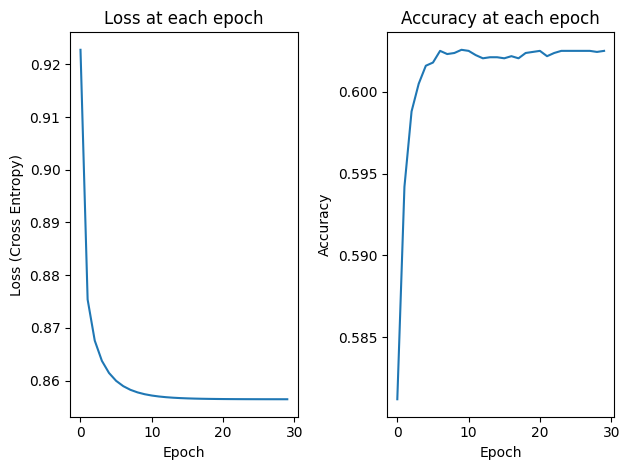

In [58]:
# Visualizations of Loss and Accuracy at each epoch Training dataset
loss = history_logistic_regression.history['loss']
epoch = history_logistic_regression.epoch
accuracy = history_logistic_regression.history['accuracy']
fig, axes = plt.subplots(1,2)
axes[0].plot(epoch,loss)
axes[0].set_title("Loss at each epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (Cross Entropy)")
axes[1].plot(epoch, accuracy)
axes[1].set_title("Accuracy at each epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()